---
**题名：** 专家并行（EP / MoE）

**类属：** expert-parallelism

**难易：** 高阶

**约时：** 一时辰

---

## 总览

于标准 Transformer 中，每层有一 **FFN（前馈网络）** — 一小型神经网络（通常两线性层间夹一激活函数），独立处理每一 token。若一 FFN 不足以用，何如？

**混合专家之法（MoE）** 以众 *专家 FFN* 及一轻便之 *门控网络*（一微型线性层，产路由之分数）代之，定夺每 token 当用何专家。专家并行（EP）者，散置诸专家于众 GPU，使模型扩其参数而不增单 token 之算力。

此册自最简之二专家 MoE 始，逐层递进，至完备之分布式 EP 暨 All-to-All 通信——每步皆以可检视之小张量示之。

### 先修之学

- PyTorch 张量之基本操作
- [00-gpu-communication](../00-gpu-communication/) — 集合通信诸操作（AllReduce、AllGather、All-to-All）
- [02-tensor-parallelism](../02-tensor-parallelism/) — 有助于解 EP+TP 之组合

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

torch.manual_seed(42)

# Consistent token colors used throughout the notebook
TOKEN_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
TOKEN_NAMES  = [f'tok{i}' for i in range(len(TOKEN_COLORS))]
EXPERT_COLORS = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']

def token_color(i):
    return TOKEN_COLORS[i % len(TOKEN_COLORS)]

## 概念与原理

### 第一层 — 若一 FFN 不足用

标准 Transformer 块有 **一** FFN 为诸 token 共享。每 token 乃一数字之向量（其**隐藏表示**，大小为 `hidden_dim` — 如 GPT-3 中为 4096）。FFN 变换此向量：`hidden_dim → 4×hidden_dim → hidden_dim`。

MoE 以 **N 个专家 FFN**（每个结构相同，然所学权重各异）及一微型**门控网络** 代之——仅一线性层，将每 token 之向量映射至 N 个分数，每专家一个。此分数定夺何专家处理何 token。

先从至简之例始：**四 token，二专家**。

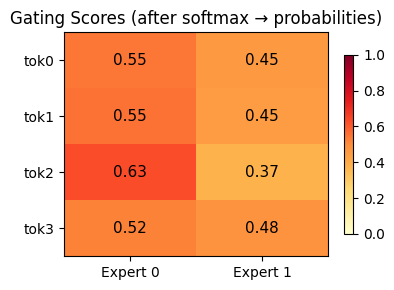

Each row sums to 1 — the gate distributes probability across experts.


In [2]:
# --- Simplest MoE: 4 tokens, 2 experts, hidden_dim=8 ---

num_tokens, hidden_dim, num_experts = 4, 8, 2

# Input: 4 tokens, each is a vector of size hidden_dim=8
x = torch.randn(num_tokens, hidden_dim)

# Gating network: a single linear layer that maps each token (dim=8) to 2 scores
gate = nn.Linear(hidden_dim, num_experts, bias=False)

# 2 expert FFNs (simplified to single linear layers for this demo)
experts = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(num_experts)])

# Step 1: Compute gating scores
raw_scores = gate(x)                    # (4, 2) — raw scores, can be any real number
# Softmax converts raw scores into probabilities that sum to 1 per token
# Higher score → higher probability → more likely to be chosen
gating_probs = F.softmax(raw_scores, dim=-1)  # (4, 2)

# Visualize gating scores as a heatmap
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(gating_probs.detach().numpy(), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'Expert {i}' for i in range(num_experts)])
ax.set_yticks(range(num_tokens));  ax.set_yticklabels([f'tok{i}' for i in range(num_tokens)])
for i in range(num_tokens):
    for j in range(num_experts):
        ax.text(j, i, f'{gating_probs[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Gating Scores (after softmax → probabilities)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

print("Each row sums to 1 — the gate distributes probability across experts.")

每 token 择门控分数**至高者**之专家（top-1 路由）。观其分配：

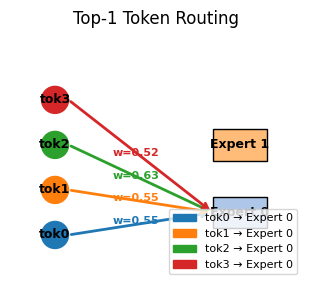

In [3]:
# Top-1 routing: each token goes to its best expert
chosen_experts = gating_probs.argmax(dim=-1)  # (4,)

fig, ax = plt.subplots(figsize=(6, 3))
# Draw tokens on the left, experts on the right
for i in range(num_tokens):
    y_tok = i * 1.0
    ax.add_patch(plt.Circle((0.5, y_tok), 0.3, color=token_color(i), zorder=3))
    ax.text(0.5, y_tok, f'tok{i}', ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)

for j in range(num_experts):
    y_exp = j * 1.5 + 0.5
    ax.add_patch(plt.Rectangle((4.0, y_exp - 0.35), 1.2, 0.7, color=EXPERT_COLORS[j], ec='black', zorder=3))
    ax.text(4.6, y_exp, f'Expert {j}', ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)

# Draw arrows from tokens to chosen experts
for i in range(num_tokens):
    y_tok = i * 1.0
    j = chosen_experts[i].item()
    y_exp = j * 1.5 + 0.5
    weight = gating_probs[i, j].item()
    ax.annotate('', xy=(4.0, y_exp), xytext=(0.8, y_tok),
                arrowprops=dict(arrowstyle='->', color=token_color(i), lw=2))
    ax.text(2.3, (y_tok + y_exp) / 2, f'w={weight:.2f}', fontsize=8, ha='center',
            color=token_color(i), fontweight='bold')

ax.set_xlim(-0.5, 6); ax.set_ylim(-1, max(num_tokens, num_experts * 1.5) + 0.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Top-1 Token Routing', fontsize=12)

# Legend
handles = [mpatches.Patch(color=token_color(i), label=f'tok{i} \u2192 Expert {chosen_experts[i].item()}')
           for i in range(num_tokens)]
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

每专家处理其所分之 token，输出以门控分数加权：

In [4]:
# Forward pass through assigned experts, weighted by gating score
output = torch.zeros_like(x)
for i in range(num_tokens):
    j = chosen_experts[i].item()
    w = gating_probs[i, j]
    expert_out = experts[j](x[i])
    output[i] = w * expert_out

print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"\nToken assignments: {['Expert ' + str(j.item()) for j in chosen_experts]}")
print(f"\nActual output values (first 4 dims):")
for i in range(num_tokens):
    print(f"  tok{i}: {output[i, :4].detach().numpy().round(3)}")

Input shape:  torch.Size([4, 8])
Output shape: torch.Size([4, 8])

Token assignments: ['Expert 0', 'Expert 0', 'Expert 0', 'Expert 0']

Actual output values (first 4 dims):
  tok0: [-0.428  0.812  0.392 -0.178]
  tok1: [-0.051  0.051  0.051  0.005]
  tok2: [ 0.808 -0.287  0.211  0.995]
  tok3: [-0.141 -0.093  0.002 -0.127]


### 第二层 — 大规模之路由

真实 MoE 模型专家甚众。今扩至 **六 token，四专家**，观路由之运作。

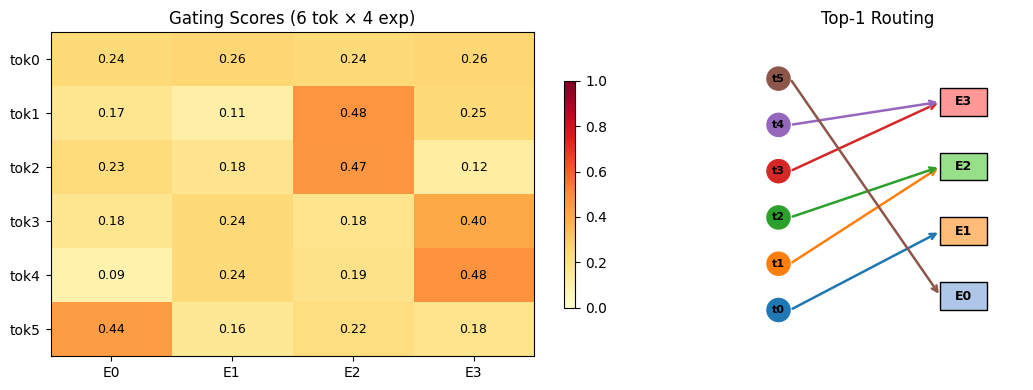

Notice: some experts may get many tokens, others get none — we'll fix this later.


In [5]:
# Scale up: 6 tokens, 4 experts
num_tokens, num_experts = 6, 4
x6 = torch.randn(num_tokens, hidden_dim)
gate4 = nn.Linear(hidden_dim, num_experts, bias=False)
experts4 = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(num_experts)])

scores = F.softmax(gate4(x6), dim=-1)  # (6, 4)
top1_experts = scores.argmax(dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Gating heatmap
ax = axes[0]
im = ax.imshow(scores.detach().numpy(), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{i}' for i in range(num_experts)])
ax.set_yticks(range(num_tokens)); ax.set_yticklabels([f'tok{i}' for i in range(num_tokens)])
for i in range(num_tokens):
    for j in range(num_experts):
        ax.text(j, i, f'{scores[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Gating Scores (6 tok \u00d7 4 exp)')
plt.colorbar(im, ax=ax, shrink=0.7)

# Right: Token flow diagram
ax = axes[1]
for i in range(num_tokens):
    ax.add_patch(plt.Circle((0.5, i), 0.25, color=token_color(i), zorder=3))
    ax.text(0.5, i, f't{i}', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)

for j in range(num_experts):
    y_exp = j * 1.4 + 0.3
    ax.add_patch(plt.Rectangle((4.0, y_exp - 0.3), 1.0, 0.6, color=EXPERT_COLORS[j], ec='black', zorder=3))
    ax.text(4.5, y_exp, f'E{j}', ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)

for i in range(num_tokens):
    j = top1_experts[i].item()
    y_exp = j * 1.4 + 0.3
    ax.annotate('', xy=(4.0, y_exp), xytext=(0.75, i),
                arrowprops=dict(arrowstyle='->', color=token_color(i), lw=1.8))

ax.set_xlim(-0.5, 5.8); ax.set_ylim(-1, 6)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Top-1 Routing')

plt.tight_layout(); plt.show()
print("Notice: some experts may get many tokens, others get none \u2014 we'll fix this later.")

**Top-2 路由**：每 token 遣往**最善之二**专家。其输出为加权之和：

$$y_i = w_{i,1} \cdot E_{j_1}(x_i) + w_{i,2} \cdot E_{j_2}(x_i)$$

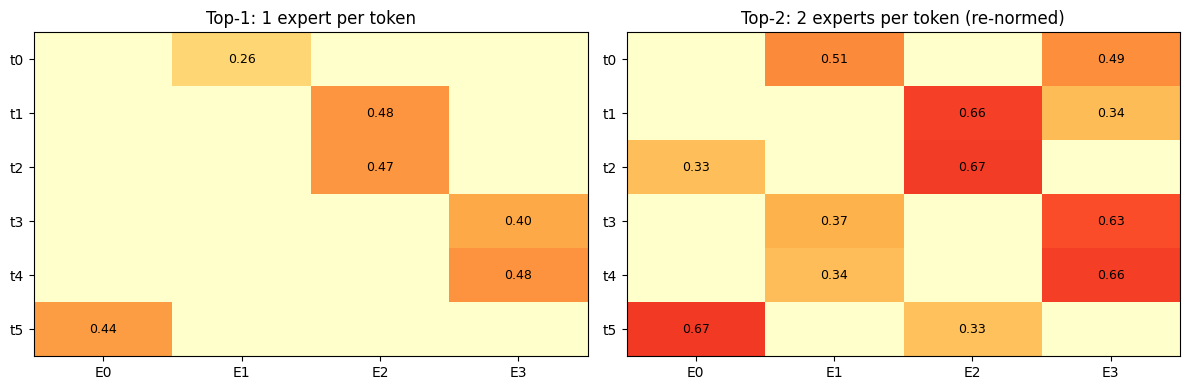

Top-2 spreads load more evenly and improves quality — each token gets a blended answer.


In [6]:
# Top-2 routing
topk_vals, topk_idx = scores.topk(2, dim=-1)  # each token picks 2 experts
# Re-normalize weights to sum to 1
topk_weights = topk_vals / topk_vals.sum(dim=-1, keepdim=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Top-1 assignments
ax = axes[0]
assignment1 = torch.zeros(num_tokens, num_experts)
for i in range(num_tokens):
    assignment1[i, top1_experts[i]] = scores[i, top1_experts[i]]
im = ax.imshow(assignment1.detach().numpy(), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
ax.set_yticks(range(num_tokens)); ax.set_yticklabels([f't{i}' for i in range(num_tokens)])
ax.set_title('Top-1: 1 expert per token')
for i in range(num_tokens):
    for j in range(num_experts):
        v = assignment1[i,j].item()
        if v > 0: ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9)

# Right: Top-2 assignments
ax = axes[1]
assignment2 = torch.zeros(num_tokens, num_experts)
for i in range(num_tokens):
    for k in range(2):
        assignment2[i, topk_idx[i, k]] = topk_weights[i, k]
im = ax.imshow(assignment2.detach().numpy(), cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
ax.set_yticks(range(num_tokens)); ax.set_yticklabels([f't{i}' for i in range(num_tokens)])
ax.set_title('Top-2: 2 experts per token (re-normed)')
for i in range(num_tokens):
    for j in range(num_experts):
        v = assignment2[i,j].item()
        if v > 0.01: ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout(); plt.show()
print("Top-2 spreads load more evenly and improves quality \u2014 each token gets a blended answer.")

**专家选择路由**者，视角倒转也：非 token 择专家，乃每**专家择其 top-k token**。如此自然均衡负载——每专家恰处理 k 个 token。

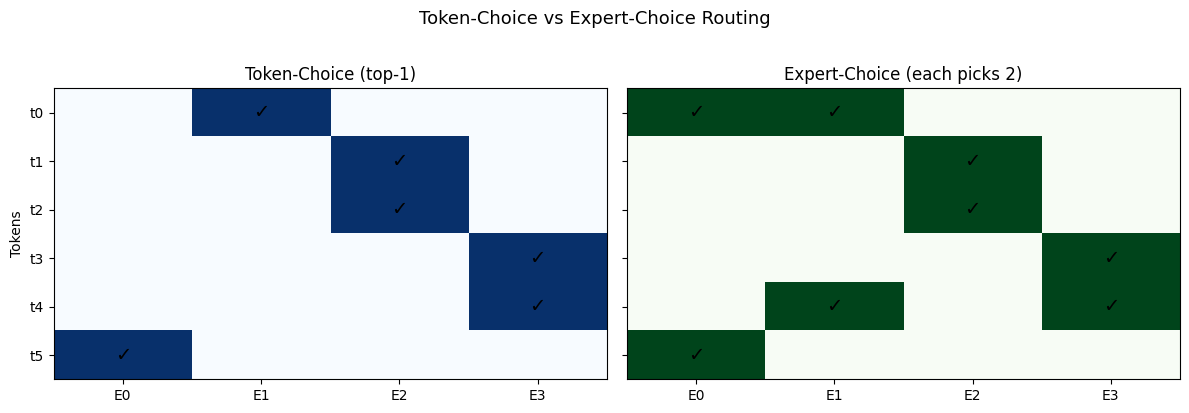

Token-choice load per expert: [1, 1, 2, 2]  (can be uneven)
Expert-choice load per expert: [2, 2, 2, 2]  (always 2 each)


In [7]:
# Expert-choice: each expert picks its top-2 tokens
k_per_expert = 2  # each expert picks 2 tokens
scores_T = scores.T  # (num_experts, num_tokens)
expert_topk_vals, expert_topk_idx = scores_T.topk(k_per_expert, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left: Token-choice (top-1)
ax = axes[0]
tc_matrix = torch.zeros(num_tokens, num_experts)
for i in range(num_tokens):
    tc_matrix[i, top1_experts[i]] = 1.0
ax.imshow(tc_matrix.detach().numpy(), cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
ax.set_yticks(range(num_tokens)); ax.set_yticklabels([f't{i}' for i in range(num_tokens)])
for i in range(num_tokens):
    for j in range(num_experts):
        if tc_matrix[i,j] > 0: ax.text(j, i, '\u2713', ha='center', va='center', fontsize=14)
ax.set_title('Token-Choice (top-1)')
ax.set_ylabel('Tokens')

# Right: Expert-choice
ax = axes[1]
ec_matrix = torch.zeros(num_tokens, num_experts)
for j in range(num_experts):
    for idx in expert_topk_idx[j]:
        ec_matrix[idx, j] = 1.0
ax.imshow(ec_matrix.detach().numpy(), cmap='Greens', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
for i in range(num_tokens):
    for j in range(num_experts):
        if ec_matrix[i,j] > 0: ax.text(j, i, '\u2713', ha='center', va='center', fontsize=14)
ax.set_title(f'Expert-Choice (each picks {k_per_expert})')

plt.suptitle('Token-Choice vs Expert-Choice Routing', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Count per expert
tc_counts = [int(tc_matrix[:, j].sum()) for j in range(num_experts)]
ec_counts = [int(ec_matrix[:, j].sum()) for j in range(num_experts)]
print(f"Token-choice load per expert: {tc_counts}  (can be uneven)")
print(f"Expert-choice load per expert: {ec_counts}  (always {k_per_expert} each)")

### 第三层 — 负载均衡之难

以 token 择专家之法，热门专家不胜其任，余者空坐。此于大规模训练中实为难题。

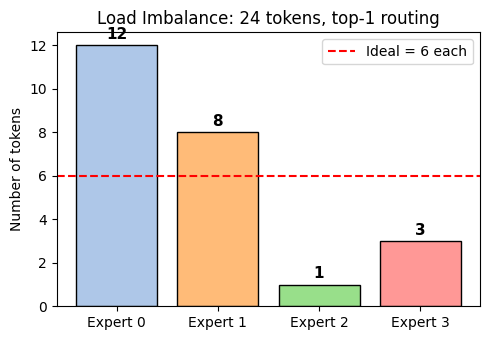

Expert 0 is overloaded — tokens queue up. Other experts waste compute.


In [8]:
# Simulate load imbalance: biased gating
torch.manual_seed(7)  # seed that produces skew
x_skew = torch.randn(24, hidden_dim)
gate_skew = nn.Linear(hidden_dim, num_experts, bias=False)

# Bias expert 0 to attract most tokens
with torch.no_grad():
    gate_skew.weight[0] += 2.0

scores_skew = F.softmax(gate_skew(x_skew), dim=-1)
assignments_skew = scores_skew.argmax(dim=-1)
counts = torch.bincount(assignments_skew, minlength=num_experts)

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(range(num_experts), counts.numpy(), color=EXPERT_COLORS[:num_experts], edgecolor='black')
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'Expert {j}' for j in range(num_experts)])
ax.set_ylabel('Number of tokens')
ax.set_title('Load Imbalance: 24 tokens, top-1 routing')
ax.axhline(y=24/num_experts, color='red', linestyle='--', label=f'Ideal = {24//num_experts} each')
ax.legend()
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(c.item()),
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print("Expert 0 is overloaded \u2014 tokens queue up. Other experts waste compute.")

**容量因子**限每专家所能受之 token 数：

$$\text{capacity} = \left\lfloor \frac{\text{tokens}}{\text{num\_experts}} \times \text{capacity\_factor} \right\rfloor$$

逾容量之 token 则**弃之**。capacity_factor 为 1.0 则完美均衡；大于 1.0 则留有余地。

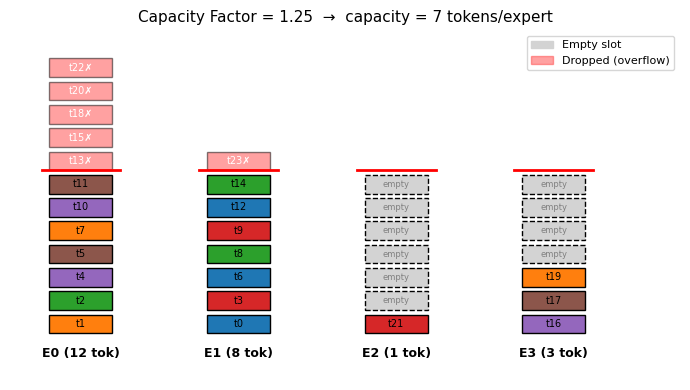

Red line = capacity limit (7). Tokens beyond it are dropped.


In [9]:
# Visualize capacity factor effect
capacity_factor = 1.25
capacity = int((24 / num_experts) * capacity_factor)  # = 7

fig, ax = plt.subplots(figsize=(7, 4))
for j in range(num_experts):
    expert_tokens = (assignments_skew == j).nonzero(as_tuple=True)[0]
    n = len(expert_tokens)
    # Draw capacity slots
    for s in range(capacity):
        x_pos = j * 2.0
        y_pos = s * 0.5
        if s < n:
            color = token_color(expert_tokens[s].item() % len(TOKEN_COLORS))
            ax.add_patch(plt.Rectangle((x_pos, y_pos), 0.8, 0.4, color=color, ec='black'))
            ax.text(x_pos + 0.4, y_pos + 0.2, f't{expert_tokens[s].item()}', ha='center', va='center', fontsize=7)
        else:
            ax.add_patch(plt.Rectangle((x_pos, y_pos), 0.8, 0.4, color='#d3d3d3', ec='black', linestyle='--'))
            ax.text(x_pos + 0.4, y_pos + 0.2, 'empty', ha='center', va='center', fontsize=6, color='gray')
    # Draw overflow (dropped tokens)
    for s in range(capacity, n):
        x_pos = j * 2.0
        y_pos = s * 0.5
        ax.add_patch(plt.Rectangle((x_pos, y_pos), 0.8, 0.4, color='#ff4444', ec='black', alpha=0.5))
        ax.text(x_pos + 0.4, y_pos + 0.2, f't{expert_tokens[s].item()}\u2717', ha='center', va='center', fontsize=7, color='white')
    # Capacity line
    ax.plot([j*2.0 - 0.1, j*2.0 + 0.9], [capacity*0.5, capacity*0.5], 'r-', lw=2)
    ax.text(j * 2.0 + 0.4, -0.5, f'E{j} ({n} tok)', ha='center', fontsize=9, fontweight='bold')

ax.set_xlim(-0.5, num_experts * 2)
ax.set_ylim(-1, max(counts.max().item(), capacity + 2) * 0.5 + 0.5)
ax.axis('off')
ax.set_title(f'Capacity Factor = {capacity_factor}  \u2192  capacity = {capacity} tokens/expert', fontsize=11)
handles = [mpatches.Patch(color='#d3d3d3', label='Empty slot'),
           mpatches.Patch(color='#ff4444', alpha=0.5, label='Dropped (overflow)')]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()
print(f"Red line = capacity limit ({capacity}). Tokens beyond it are dropped.")

**辅助负载均衡损失** — 一额外之损失项，加于主训练损失（如交叉熵）之上，专为修此不均之弊也。其督促门控网络均匀分配 token，惩罚每专家所得 token 之比（$f_j$）与路由概率（$P_j$）之关联：

$$\mathcal{L}_{aux} = \alpha \cdot N \cdot \sum_{j=1}^{N} f_j \cdot P_j$$

其中 $f_j = \frac{\text{分配予专家 } j \text{ 之 token 数}}{\text{token 总数}}$，$P_j = \frac{1}{T}\sum_i p_{i,j}$

系数 $\alpha$（通常为 0.01）控均衡之力度与自由路由之间的平衡。

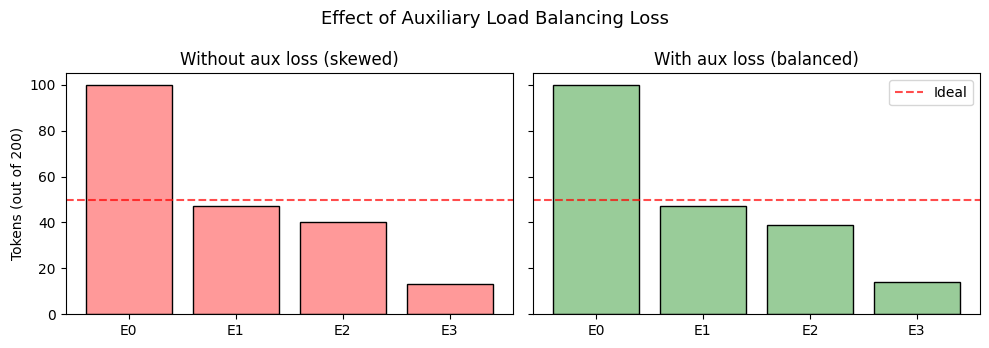

In [10]:
# Simulate training with and without aux loss
torch.manual_seed(7)
gate_no_aux = nn.Linear(hidden_dim, num_experts, bias=False)
gate_with_aux = nn.Linear(hidden_dim, num_experts, bias=False)
gate_with_aux.load_state_dict(gate_no_aux.state_dict())

with torch.no_grad():
    gate_no_aux.weight[0] += 2.0
    gate_with_aux.weight[0] += 2.0

x_train = torch.randn(200, hidden_dim)
alpha = 0.01  # aux loss coefficient

# Train gate_with_aux for a few steps to balance
optimizer = torch.optim.SGD(gate_with_aux.parameters(), lr=0.5)
for step in range(50):
    probs = F.softmax(gate_with_aux(x_train), dim=-1)
    assignments = probs.argmax(dim=-1)
    f = torch.zeros(num_experts)
    for j in range(num_experts):
        f[j] = (assignments == j).float().mean()
    P = probs.mean(dim=0)
    aux_loss = alpha * num_experts * (f * P).sum()
    optimizer.zero_grad()
    aux_loss.backward()
    optimizer.step()

# Compare distributions
scores_no_aux = F.softmax(gate_no_aux(x_train), dim=-1).argmax(dim=-1)
scores_with_aux = F.softmax(gate_with_aux(x_train), dim=-1).argmax(dim=-1)
counts_no = torch.bincount(scores_no_aux, minlength=num_experts).float()
counts_with = torch.bincount(scores_with_aux, minlength=num_experts).float()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

ax = axes[0]
ax.bar(range(num_experts), counts_no.numpy(), color='#ff9999', edgecolor='black')
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
ax.set_ylabel('Tokens (out of 200)')
ax.set_title('Without aux loss (skewed)')
ax.axhline(y=200/num_experts, color='red', linestyle='--', alpha=0.7)

ax = axes[1]
ax.bar(range(num_experts), counts_with.numpy(), color='#99cc99', edgecolor='black')
ax.set_xticks(range(num_experts)); ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
ax.set_title('With aux loss (balanced)')
ax.axhline(y=200/num_experts, color='red', linestyle='--', alpha=0.7, label='Ideal')
ax.legend()

plt.suptitle('Effect of Auxiliary Load Balancing Loss', fontsize=13)
plt.tight_layout(); plt.show()

## 图解示意

### 第四层 — 专家散布于诸 GPU：All-to-All

前此诸专家皆居一处。实际中专家**散布于众 GPU** — 每 GPU 托若干专家。Token 须传至正确之 GPU。此需 **All-to-All** 通信。

**集合操作**者，众 GPU 同时参与之协同通信模式也（异于点对点之发送）。汝或知 **AllReduce**（众人贡献数据而得同一求和之果）及 **AllGather**（众人得全部数据）。**All-to-All** 则异：每 GPU 向*每一*他 GPU 发*不同之*数据块——犹邮驿之分拣，每信箱既发亦收不同之书信。

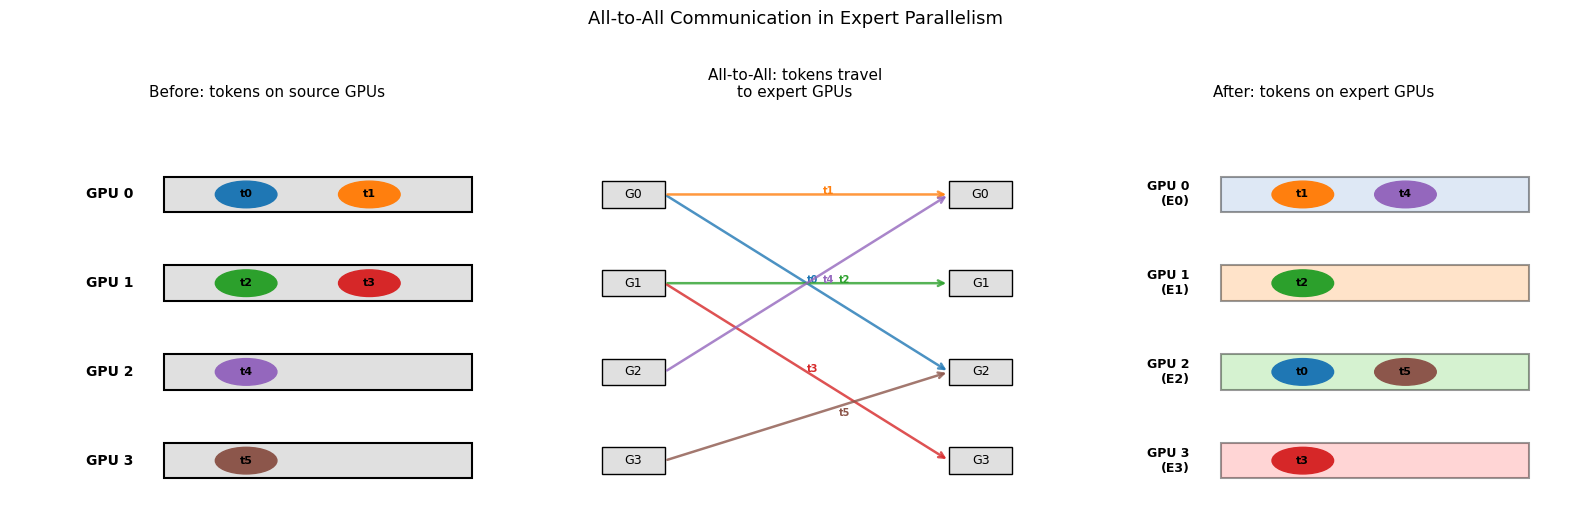

In [11]:
# All-to-All: 4 GPUs, 6 tokens distributed across them
num_gpus = 4

# Each GPU starts with some tokens (simulating batch distribution)
# Token assignment: tok0,tok1 on GPU0; tok2,tok3 on GPU1; tok4 on GPU2; tok5 on GPU3
gpu_tokens_before = {0: [0, 1], 1: [2, 3], 2: [4], 3: [5]}

# After gating, tokens need to go to their expert's GPU
# Suppose routing: tok0->E2, tok1->E0, tok2->E1, tok3->E3, tok4->E0, tok5->E2
token_to_expert = {0: 2, 1: 0, 2: 1, 3: 3, 4: 0, 5: 2}  # expert j lives on GPU j

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Before All-to-All (tokens on source GPUs)
ax = axes[0]
for g in range(num_gpus):
    y = (num_gpus - 1 - g) * 2
    ax.add_patch(plt.Rectangle((0, y - 0.4), 3, 0.8, color='#e0e0e0', ec='black', lw=1.5))
    ax.text(-0.3, y, f'GPU {g}', ha='right', va='center', fontsize=10, fontweight='bold')
    for k, tok_id in enumerate(gpu_tokens_before[g]):
        ax.add_patch(plt.Circle((0.8 + k * 1.2, y), 0.3, color=token_color(tok_id), zorder=3))
        ax.text(0.8 + k * 1.2, y, f't{tok_id}', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
ax.set_xlim(-1.5, 3.5); ax.set_ylim(-1, num_gpus * 2)
ax.axis('off'); ax.set_title('Before: tokens on source GPUs', fontsize=11)

# Panel 2: Arrows showing movement
ax = axes[1]
for g in range(num_gpus):
    y_src = (num_gpus - 1 - g) * 2
    ax.add_patch(plt.Rectangle((-0.2, y_src - 0.3), 0.8, 0.6, color='#e0e0e0', ec='black'))
    ax.text(0.2, y_src, f'G{g}', ha='center', va='center', fontsize=9)
    ax.add_patch(plt.Rectangle((4.2, y_src - 0.3), 0.8, 0.6, color='#e0e0e0', ec='black'))
    ax.text(4.6, y_src, f'G{g}', ha='center', va='center', fontsize=9)

for g in range(num_gpus):
    for tok_id in gpu_tokens_before[g]:
        src_y = (num_gpus - 1 - g) * 2
        dst_gpu = token_to_expert[tok_id]
        dst_y = (num_gpus - 1 - dst_gpu) * 2
        ax.annotate('', xy=(4.2, dst_y), xytext=(0.6, src_y),
                    arrowprops=dict(arrowstyle='->', color=token_color(tok_id), lw=1.8, alpha=0.8))
        mid_x = 2.4 + (tok_id % 3) * 0.2
        mid_y = (src_y + dst_y) / 2
        ax.text(mid_x, mid_y, f't{tok_id}', fontsize=7, color=token_color(tok_id), fontweight='bold')

ax.set_xlim(-1, 5.5); ax.set_ylim(-1, num_gpus * 2)
ax.axis('off'); ax.set_title('All-to-All: tokens travel\nto expert GPUs', fontsize=11)

# Panel 3: After All-to-All (tokens on expert GPUs)
ax = axes[2]
gpu_tokens_after = {g: [] for g in range(num_gpus)}
for tok_id, exp_id in token_to_expert.items():
    gpu_tokens_after[exp_id].append(tok_id)

for g in range(num_gpus):
    y = (num_gpus - 1 - g) * 2
    ax.add_patch(plt.Rectangle((0, y - 0.4), 3, 0.8, color=EXPERT_COLORS[g], ec='black', lw=1.5, alpha=0.4))
    ax.text(-0.3, y, f'GPU {g}\n(E{g})', ha='right', va='center', fontsize=9, fontweight='bold')
    for k, tok_id in enumerate(gpu_tokens_after[g]):
        ax.add_patch(plt.Circle((0.8 + k * 1.0, y), 0.3, color=token_color(tok_id), zorder=3))
        ax.text(0.8 + k * 1.0, y, f't{tok_id}', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)

ax.set_xlim(-1.5, 3.5); ax.set_ylim(-1, num_gpus * 2)
ax.axis('off'); ax.set_title('After: tokens on expert GPUs', fontsize=11)

plt.suptitle('All-to-All Communication in Expert Parallelism', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

All-to-All 与他集合操作较之如何？

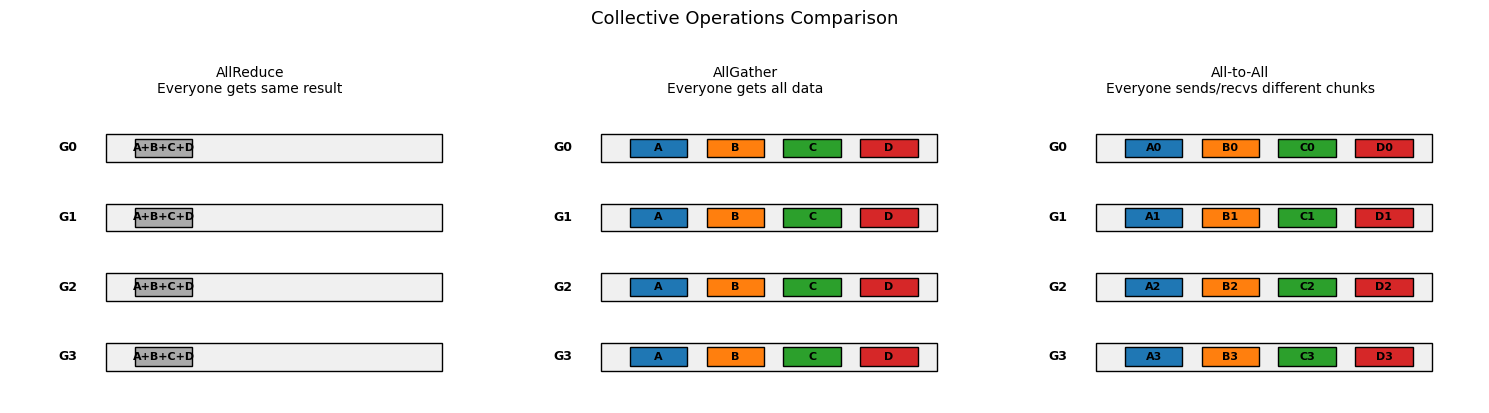

All-to-All is unique: each GPU sends DIFFERENT data to EACH other GPU.
This is exactly what MoE needs — different tokens go to different experts.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gpu_data = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
gpu_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def draw_gpus(ax, data_per_gpu, title):
    for g in range(4):
        y = (3 - g) * 1.5
        ax.add_patch(plt.Rectangle((0, y - 0.3), 3.5, 0.6, color='#f0f0f0', ec='black'))
        ax.text(-0.3, y, f'G{g}', ha='right', va='center', fontsize=9, fontweight='bold')
        items = data_per_gpu[g]
        for k, (label, color) in enumerate(items):
            ax.add_patch(plt.Rectangle((0.3 + k * 0.8, y - 0.2), 0.6, 0.4, color=color, ec='black'))
            ax.text(0.3 + k * 0.8 + 0.3, y, label, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(-1, 4); ax.set_ylim(-1, 5.5); ax.axis('off')
    ax.set_title(title, fontsize=10)

# AllReduce: everyone gets sum of all
draw_gpus(axes[0],
    {g: [('A+B+C+D', '#aaaaaa')] for g in range(4)},
    'AllReduce\nEveryone gets same result')

# AllGather: everyone gets all data
draw_gpus(axes[1],
    {g: [(d, gpu_colors[i]) for i, d in gpu_data.items()] for g in range(4)},
    'AllGather\nEveryone gets all data')

# All-to-All: everyone gets different data from each
a2a_result = {
    0: [('A0', gpu_colors[0]), ('B0', gpu_colors[1]), ('C0', gpu_colors[2]), ('D0', gpu_colors[3])],
    1: [('A1', gpu_colors[0]), ('B1', gpu_colors[1]), ('C1', gpu_colors[2]), ('D1', gpu_colors[3])],
    2: [('A2', gpu_colors[0]), ('B2', gpu_colors[1]), ('C2', gpu_colors[2]), ('D2', gpu_colors[3])],
    3: [('A3', gpu_colors[0]), ('B3', gpu_colors[1]), ('C3', gpu_colors[2]), ('D3', gpu_colors[3])],
}
draw_gpus(axes[2], a2a_result,
    'All-to-All\nEveryone sends/recvs different chunks')

plt.suptitle('Collective Operations Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print("All-to-All is unique: each GPU sends DIFFERENT data to EACH other GPU.")
print("This is exactly what MoE needs \u2014 different tokens go to different experts.")

完备之 EP 通信周期含两次 All-to-All 操作：
1. **分发（Dispatch）**：遣 token 至专家所在之 GPU
2. **计算（Compute）**：每专家于本地处理其 token
3. **收集（Gather）**：遣结果归于源 GPU

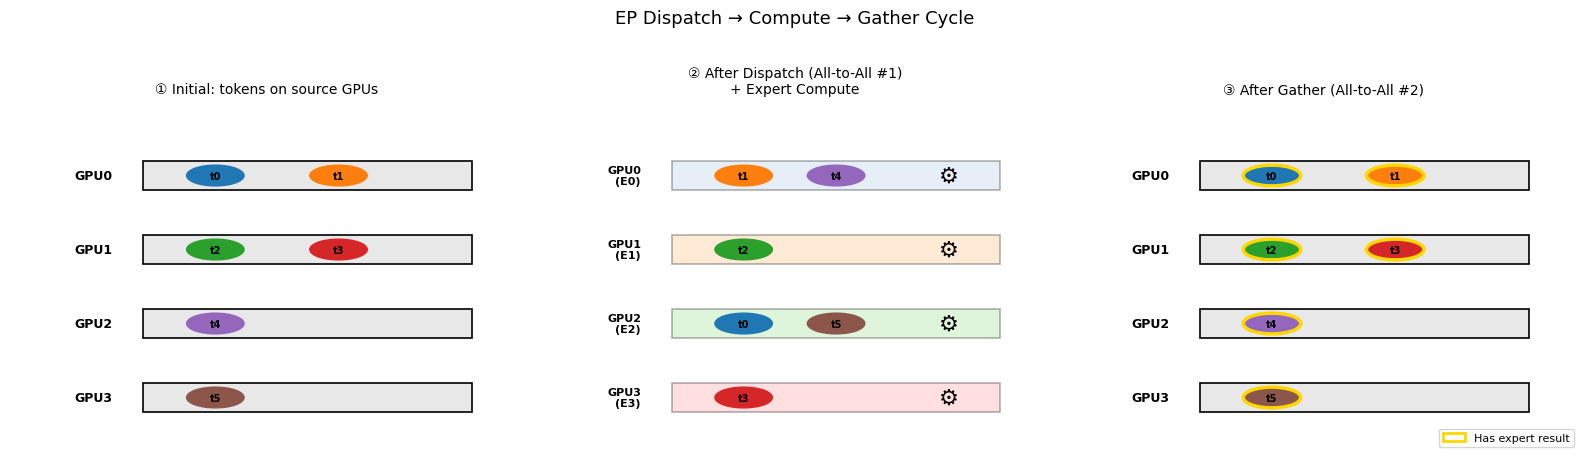

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
titles = ['\u2460 Initial: tokens on source GPUs',
          '\u2461 After Dispatch (All-to-All #1)\n+ Expert Compute',
          '\u2462 After Gather (All-to-All #2)']

# Reuse earlier data
for panel, ax in enumerate(axes):
    for g in range(num_gpus):
        y = (num_gpus - 1 - g) * 2.0
        if panel == 0:
            # Source GPUs with their local tokens
            ax.add_patch(plt.Rectangle((-0.2, y - 0.4), 3.2, 0.8, color='#e8e8e8', ec='black', lw=1.2))
            ax.text(-0.5, y, f'GPU{g}', ha='right', va='center', fontsize=9, fontweight='bold')
            for k, tok in enumerate(gpu_tokens_before[g]):
                ax.add_patch(plt.Circle((0.5 + k * 1.2, y), 0.28, color=token_color(tok), zorder=3))
                ax.text(0.5 + k * 1.2, y, f't{tok}', ha='center', va='center', fontsize=7, fontweight='bold', zorder=4)
        elif panel == 1:
            # Expert GPUs after dispatch
            ax.add_patch(plt.Rectangle((-0.2, y - 0.4), 3.2, 0.8, color=EXPERT_COLORS[g], alpha=0.3, ec='black', lw=1.2))
            ax.text(-0.5, y, f'GPU{g}\n(E{g})', ha='right', va='center', fontsize=8, fontweight='bold')
            for k, tok in enumerate(gpu_tokens_after[g]):
                ax.add_patch(plt.Circle((0.5 + k * 0.9, y), 0.28, color=token_color(tok), zorder=3))
                ax.text(0.5 + k * 0.9, y, f't{tok}', ha='center', va='center', fontsize=7, fontweight='bold', zorder=4)
            if gpu_tokens_after[g]:
                ax.text(2.5, y, '\u2699', fontsize=16, ha='center', va='center')
        else:
            # Back to source GPUs with results
            ax.add_patch(plt.Rectangle((-0.2, y - 0.4), 3.2, 0.8, color='#e8e8e8', ec='black', lw=1.2))
            ax.text(-0.5, y, f'GPU{g}', ha='right', va='center', fontsize=9, fontweight='bold')
            for k, tok in enumerate(gpu_tokens_before[g]):
                ax.add_patch(plt.Circle((0.5 + k * 1.2, y), 0.28, color=token_color(tok), zorder=3))
                ax.add_patch(plt.Circle((0.5 + k * 1.2, y), 0.28, fill=False, ec='gold', lw=2.5, zorder=4))
                ax.text(0.5 + k * 1.2, y, f't{tok}', ha='center', va='center', fontsize=7, fontweight='bold', zorder=5)

    ax.set_xlim(-1.5, 3.5); ax.set_ylim(-1.5, num_gpus * 2)
    ax.axis('off'); ax.set_title(titles[panel], fontsize=10)

# Legend for panel 3
handles = [mpatches.Patch(facecolor='white', edgecolor='gold', lw=2, label='Has expert result')]
axes[2].legend(handles=handles, loc='lower right', fontsize=8)

plt.suptitle('EP Dispatch \u2192 Compute \u2192 Gather Cycle', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

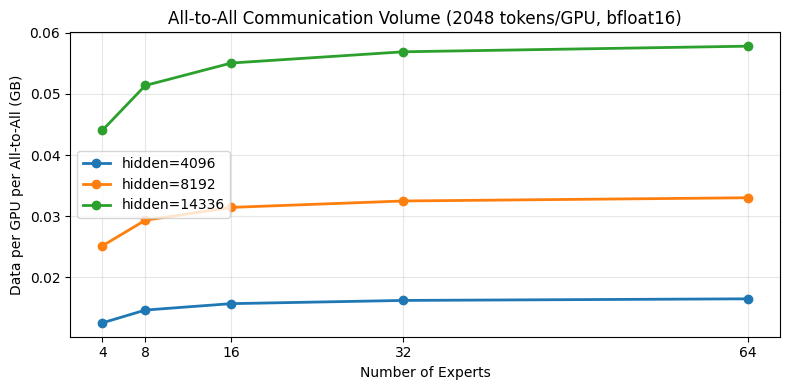

Communication grows with hidden_dim but plateaus with expert count (approaches tokens × hidden).


In [14]:
# Communication volume analysis
# Per-GPU data volume for All-to-All in EP:
# Each GPU sends (tokens_per_gpu / num_experts) * hidden_dim to each other GPU
# Total send per GPU ≈ tokens_per_gpu * hidden_dim * (1 - 1/num_experts)

hidden_dims = [4096, 8192, 14336]  # typical transformer hidden dims
expert_counts = [4, 8, 16, 32, 64]
tokens_per_gpu = 2048  # typical micro-batch

fig, ax = plt.subplots(figsize=(8, 4))
for h_dim in hidden_dims:
    volumes = []
    for n_exp in expert_counts:
        # Total bytes sent per GPU per All-to-All
        # bfloat16 = 2 bytes per number (a 16-bit floating point format
        # commonly used in training — half the memory of float32, with
        # the same exponent range, just less decimal precision)
        vol_bytes = tokens_per_gpu * h_dim * (1 - 1/n_exp) * 2
        vol_gb = vol_bytes / 1e9
        volumes.append(vol_gb)
    ax.plot(expert_counts, volumes, 'o-', label=f'hidden={h_dim}', lw=2)

ax.set_xlabel('Number of Experts')
ax.set_ylabel('Data per GPU per All-to-All (GB)')
ax.set_title('All-to-All Communication Volume (2048 tokens/GPU, bfloat16)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(expert_counts)
plt.tight_layout(); plt.show()
print("Communication grows with hidden_dim but plateaus with expert count (approaches tokens × hidden).")

> ⚠️ **须 GPU** — 于多卡 GPU 机器运行此格（推荐四卡以上）。

In [ ]:
# [GPU-REQUIRED]
# Real All-to-All on 4 GPUs using torch.distributed
# Run on a multi-GPU machine (4+ GPUs recommended)
#
# Save this as a script and run with: torchrun --nproc_per_node=4 all_to_all_demo.py
#
# import os
# import torch
# import torch.distributed as dist
#
# def main():
#     dist.init_process_group("nccl")
#     rank = dist.get_rank()
#     world_size = dist.get_world_size()
#     device = torch.device(f"cuda:{rank}")
#
#     # Each GPU has 6 tokens, will send different chunks to each other GPU
#     tokens_per_gpu = 6
#     hidden_dim = 8
#     chunk_size = tokens_per_gpu // world_size  # 6/4 is not even, so we use padding
#     chunk_size = 2  # send 2 tokens to each GPU
#
#     # Input: each GPU has its own tokens
#     input_tensor = torch.randn(tokens_per_gpu, hidden_dim, device=device) + rank
#     print(f"[Rank {rank}] Input shape: {input_tensor.shape}, mean: {input_tensor.mean():.2f}")
#
#     # Split input into chunks for each destination GPU
#     input_splits = list(input_tensor.reshape(world_size, chunk_size, hidden_dim))
#     output_splits = [torch.empty(chunk_size, hidden_dim, device=device) for _ in range(world_size)]
#
#     dist.all_to_all(output_splits, input_splits)
#
#     output_tensor = torch.cat(output_splits, dim=0)
#     print(f"[Rank {rank}] Output shape: {output_tensor.shape}")
#     print(f"[Rank {rank}] Output chunk means: {[f'{c.mean():.2f}' for c in output_splits]}")
#     # Each output chunk should have mean ~ source rank
#
#     dist.destroy_process_group()
#
# if __name__ == "__main__":
#     main()

## 于 LLM 中之应用

### 第五层 — EP 与他策略之合

于生产中，EP 鲜独用也。常与以下策略合用：

- **数据并行（DP）**：将全模型复制于众 GPU，每 GPU 处理不同批次之数据，而后以 AllReduce 同步梯度。简便然费内存——每 GPU 皆持全部参数。
- **张量并行（TP）**：将单层之权重矩阵切分于众 GPU（如一部分列于 GPU 0，余列于 GPU 1）。减每 GPU 之内存，然每层内增 AllReduce 通信。

EP 增第三维度：散置*不同之专家*于*不同之 GPU*。观其如何组合。

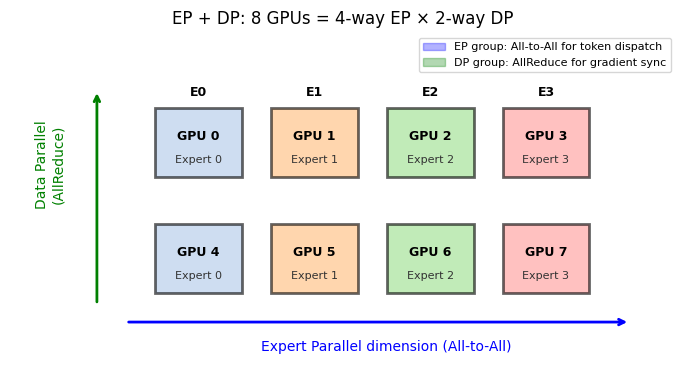

Same expert on GPU 0 and GPU 4 — they're DP replicas.
EP group (horizontal): experts exchange tokens via All-to-All.
DP group (vertical): replicas sync gradients via AllReduce.


In [15]:
# EP + DP: 2D GPU grid
# Example: 8 GPUs arranged as 4-way EP x 2-way DP
fig, ax = plt.subplots(figsize=(8, 4))
ep_size, dp_size = 4, 2
gpu_id = 0

for dp in range(dp_size):
    for ep in range(ep_size):
        x = ep * 2.0
        y = (dp_size - 1 - dp) * 2.0
        # Color by EP group
        color = EXPERT_COLORS[ep]
        ax.add_patch(plt.Rectangle((x, y), 1.5, 1.2, color=color, ec='black', lw=2, alpha=0.6))
        ax.text(x + 0.75, y + 0.7, f'GPU {gpu_id}', ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(x + 0.75, y + 0.3, f'Expert {ep}', ha='center', va='center', fontsize=8, color='#333')
        # DP replica marker
        if dp == 0:
            ax.text(x + 0.75, y + 1.4, f'E{ep}', ha='center', fontsize=9, fontweight='bold')
        gpu_id += 1

# Axis labels
ax.annotate('', xy=(8.2, -0.5), xytext=(-0.5, -0.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax.text(4, -1.0, 'Expert Parallel dimension (All-to-All)', ha='center', fontsize=10, color='blue')

ax.annotate('', xy=(-1.0, 3.5), xytext=(-1.0, -0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.text(-1.8, 1.5, 'Data Parallel\n(AllReduce)', ha='center', fontsize=10, color='green', rotation=90)

ax.set_xlim(-2.5, 9); ax.set_ylim(-1.5, 4.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('EP + DP: 8 GPUs = 4-way EP \u00d7 2-way DP', fontsize=12)

handles = [mpatches.Patch(color='blue', alpha=0.3, label='EP group: All-to-All for token dispatch'),
           mpatches.Patch(color='green', alpha=0.3, label='DP group: AllReduce for gradient sync')]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

print("Same expert on GPU 0 and GPU 4 \u2014 they're DP replicas.")
print("EP group (horizontal): experts exchange tokens via All-to-All.")
print("DP group (vertical): replicas sync gradients via AllReduce.")

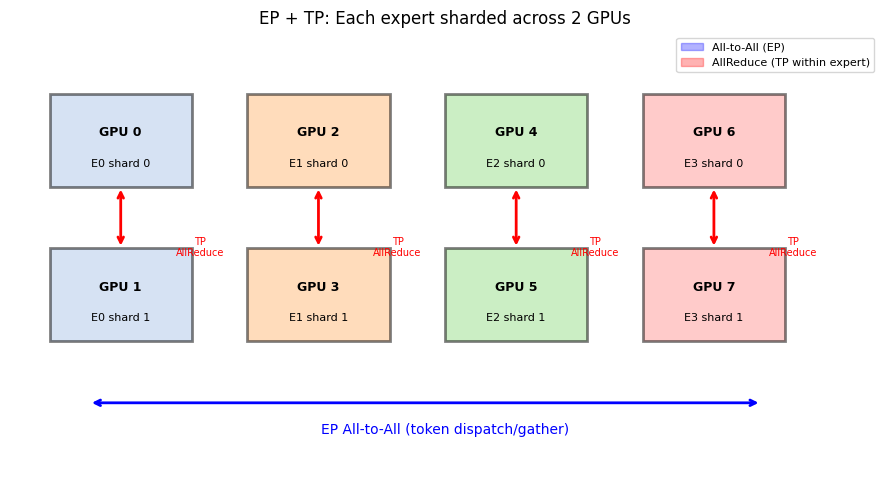

Two levels of communication:
  1. All-to-All across experts (EP) — route tokens to the right expert
  2. AllReduce within each expert (TP) — aggregate sharded computation


In [16]:
# EP + TP: each expert's FFN is further sharded across GPUs
fig, ax = plt.subplots(figsize=(9, 5))

# 8 GPUs: 4 experts, each sharded across 2 GPUs (TP=2)
tp_size = 2
n_experts_shown = 4

for e in range(n_experts_shown):
    for t in range(tp_size):
        x = e * 2.5
        y = (tp_size - 1 - t) * 2.0
        gpu = e * tp_size + t
        ax.add_patch(plt.Rectangle((x, y), 1.8, 1.2, color=EXPERT_COLORS[e], ec='black', lw=2, alpha=0.5))
        ax.text(x + 0.9, y + 0.7, f'GPU {gpu}', ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(x + 0.9, y + 0.3, f'E{e} shard {t}', ha='center', va='center', fontsize=8)
    # TP AllReduce arrow between shards
    ax.annotate('', xy=(e*2.5 + 0.9, 0.0 + 1.2), xytext=(e*2.5 + 0.9, 2.0),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(e*2.5 + 1.9, 1.1, 'TP\nAllReduce', fontsize=7, color='red', ha='center')

# EP All-to-All arrow across experts
y_arrow = -0.8
ax.annotate('', xy=(n_experts_shown * 2.5 - 1, y_arrow), xytext=(0.5, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(n_experts_shown * 1.25, y_arrow - 0.4, 'EP All-to-All (token dispatch/gather)',
        fontsize=10, color='blue', ha='center')

ax.set_xlim(-0.5, n_experts_shown * 2.5 + 0.5); ax.set_ylim(-1.8, 4)
ax.axis('off')
ax.set_title('EP + TP: Each expert sharded across 2 GPUs', fontsize=12)

handles = [mpatches.Patch(color='blue', alpha=0.3, label='All-to-All (EP)'),
           mpatches.Patch(color='red', alpha=0.3, label='AllReduce (TP within expert)')]
ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

print("Two levels of communication:")
print("  1. All-to-All across experts (EP) \u2014 route tokens to the right expert")
print("  2. AllReduce within each expert (TP) \u2014 aggregate sharded computation")

### 当世 MoE 模型之配置

| 模型 | 专家总数 | 激活专家 (top-k) | 隐藏维度 | 专家之大 | 并行之策 |
|-------|:---:|:---:|:---:|:---:|---|
| **Mixtral 8×7B** | 八 | 二 | 4096 | 每专家 7B 参数 | 八 GPU EP，DP 副本 |
| **DeepSeek-V2** | 百六十 | 六 | 5120 | 较小之路由专家 | EP + DP + TP，细粒度路由 |
| **Grok-1** | 八 | 二 | 6144 | 每专家约 33B 参数 | EP8 × TP?（架构已示，基建未明）|
| **Switch Transformer** | 至多 2048 | 一 | 不定 | 每专家较小 | TPU 集群 EP，top-1 路由 |

要旨：MoE 使扩**总参数量**（增专家）而不增**单 token 之算力**（仅 k 专家活跃）。

## Megatron 考据

Megatron-LM 于 `megatron/core/transformer/moe/` 中实现 MoE：

| 文件 | 用途 |
|------|---------|
| `router.py` | Top-k 及专家选择路由之逻辑，softmax 门控 |
| `token_dispatcher.py` | 处理 All-to-All 分发与收集，容量之限制 |
| `experts.py` | 专家 FFN 之定义，分组 GEMM 以增效率 |
| `moe_layer.py` | 合路由器、分发器、专家为一可替换之 MoE 层 |
| `moe_utils.py` | 辅助损失之计算，负载均衡之指标 |

Megatron-LM 之要设计：
- **分组 GEMM**（通用矩阵乘法）：非逐一运行每专家之矩阵乘法，而将诸专家之 GEMM 批量化为单 GPU kernel——大幅增硬件之利用率
- **Token 排列**：token 于分发前按专家分配排序，成连续内存访问（GPU 读写连续内存时速度快甚）
- **通信计算重叠**：分发 All-to-All 尽可能与专家计算重叠而行——当一组 token 方传输时，另一组已在处理中

## 总结与延伸

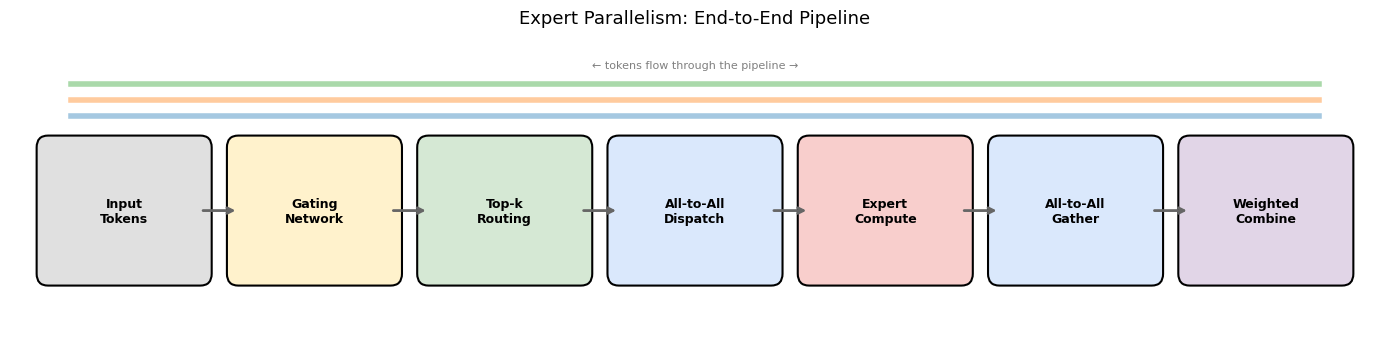

In [17]:
# Visual summary: the full EP pipeline
fig, ax = plt.subplots(figsize=(14, 3.5))

steps = [
    ('Input\nTokens', '#e0e0e0', 0),
    ('Gating\nNetwork', '#fff2cc', 2.5),
    ('Top-k\nRouting', '#d5e8d4', 5),
    ('All-to-All\nDispatch', '#dae8fc', 7.5),
    ('Expert\nCompute', '#f8cecc', 10),
    ('All-to-All\nGather', '#dae8fc', 12.5),
    ('Weighted\nCombine', '#e1d5e7', 15),
]

for label, color, x in steps:
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.2), 2, 1.6, boxstyle='round,pad=0.15',
                                      facecolor=color, edgecolor='black', lw=1.5))
    ax.text(x + 1, 1.0, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Arrows between steps
for i in range(len(steps) - 1):
    x1 = steps[i][2] + 2.0
    x2 = steps[i+1][2]
    ax.annotate('', xy=(x2, 1.0), xytext=(x1, 1.0),
                arrowprops=dict(arrowstyle='->', lw=2, color='#666'))

# Token flow indicators
for i, tok_id in enumerate([0, 1, 2]):
    ax.plot([0.3, 16.7], [2.2 + i*0.2, 2.2 + i*0.2], '-', color=token_color(tok_id), alpha=0.4, lw=4)

ax.text(8.5, 2.8, '\u2190 tokens flow through the pipeline \u2192', ha='center', fontsize=8, color='gray')
ax.set_xlim(-0.5, 17.5); ax.set_ylim(-0.5, 3.2)
ax.axis('off')
ax.set_title('Expert Parallelism: End-to-End Pipeline', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### 要旨

- **MoE** 扩模型参数而不增单 token 计算——N 专家中仅 k 者活跃
- **门控**定每 token 用何专家；**top-k** 与 **专家选择** 为主要路由之策
- **容量因子** + **辅助损失**防负载之不均与专家之坍缩
- **All-to-All** 为 EP 之独特通信原语：token 传至专家 GPU 而复返
- EP 与 **DP**（复制专家）及 **TP**（分片专家权重）合用于生产之规模

### 延伸阅读

- [Switch Transformers](https://arxiv.org/abs/2101.03961) — Fedus 等，辛丑年（2021），简化之 MoE，top-1 路由
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088) — Jiang 等，甲辰年（2024），Mixtral 8×7B 之架构
- [GShard](https://arxiv.org/abs/2006.16668) — Lepikhin 等，庚子年（2020），MoE 扩至 600B 参数
- [DeepSeek-V2](https://arxiv.org/abs/2405.04434) — DeepSeek-AI，甲辰年（2024），细粒度专家路由
- [ST-MoE](https://arxiv.org/abs/2202.08906) — Zoph 等，壬寅年（2022），设计稳固之 MoE 模型
- [Megatron-LM MoE](https://github.com/NVIDIA/Megatron-LM/tree/main/megatron/core/transformer/moe) — NVIDIA 之生产级实现